# Dry Bean Variety Classification

This case study develops a multiclass classification workflow for distinguishing seven registered dry bean varieties from geometric features extracted by a computer vision system.

The project focuses on multiclass evaluation, feature scaling, linear and nonlinear SVMs, PCA, hyperparameter tuning, class-level error analysis, and permutation importance.

## Dataset

The **Dry Bean** dataset from the UCI Machine Learning Repository contains 13,611 observations, 16 numerical features, and 7 classes:

`SEKER`, `BARBUNYA`, `BOMBAY`, `CALI`, `DERMASON`, `HOROZ`, and `SIRA`.

The features describe geometric properties such as area, perimeter, axis lengths, eccentricity, compactness, roundness, and shape factors. The notebook downloads the official UCI archive automatically when the local dataset is not available.

## 1. Setup

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pandas.plotting import scatter_matrix
from scipy.io import arff

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

## 2. Data loading

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/602/dry%2Bbean%2Bdataset.zip"

DATA_DIR = Path("data") / "dry_bean"
ZIP_PATH = DATA_DIR / "dry_bean_dataset.zip"
ARFF_PATH = DATA_DIR / "DryBeanDataset" / "Dry_Bean_Dataset.arff"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not ARFF_PATH.exists():
    if not ZIP_PATH.exists():
        print("Downloading Dry Bean dataset from UCI...")
        urlretrieve(DATA_URL, ZIP_PATH)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)

raw_data, metadata = arff.loadarff(ARFF_PATH)
df = pd.DataFrame(raw_data)

df["Class"] = df["Class"].str.decode("utf-8")

print("Raw shape:", df.shape)
df.head()

Extracting dataset...
Raw shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 3. Data quality and train/test split

The raw dataset contains no native missing values. It does contain **68 exact duplicate rows**; the same 68 duplicates are found when the class column is ignored. Because the available data does not provide a sample identifier that would allow those rows to be established as independent repeated measurements, one copy of each exact duplicate is retained.

After deduplication, the modeling dataset contains **13,543 observations**.

The cleaned data is split 80/20 using a stratified random split. The test set is held out before exploratory analysis and model selection.

In [3]:
print("Missing values:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print(
    "Duplicate feature vectors:",
    int(df.drop(columns="Class").duplicated().sum()),
)

clean_df = df.drop_duplicates().reset_index(drop=True)

X = clean_df.drop(columns="Class")
y = clean_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

train_df = X_train.copy()
train_df["Class"] = y_train

test_df = X_test.copy()
test_df["Class"] = y_test

print("Clean shape:", clean_df.shape)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Missing values: 0
Exact duplicate rows: 68
Duplicate feature vectors: 68
Clean shape: (13543, 17)
Training rows: 10834
Test rows: 2709


## 4. Exploratory analysis

The class distribution is not perfectly balanced: `DERMASON` is the largest class and `BOMBAY` is the smallest. Accuracy is therefore useful but is complemented with balanced accuracy, macro F1, weighted F1, and per-class metrics so that performance on smaller classes remains visible.

In [4]:
class_distribution = (
    train_df.groupby("Class", as_index=False)
            .agg(class_count=("Class", "count"))
)

class_distribution["class_proportion"] = (
    class_distribution["class_count"] / len(train_df)
)

class_distribution = class_distribution.sort_values(
    "class_count",
    ascending=False,
)

class_distribution

,Class,class_count,class_proportion
3,DERMASON,2837,0.261861
6,SIRA,2109,0.194665
5,SEKER,1621,0.149622
4,HOROZ,1488,0.137345
2,CALI,1304,0.120362
0,BARBUNYA,1057,0.097563
1,BOMBAY,418,0.038582


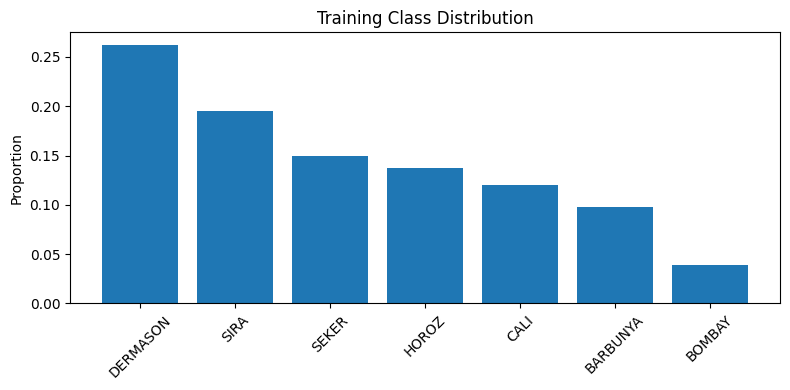

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(
    class_distribution["Class"],
    class_distribution["class_proportion"],
)
plt.ylabel("Proportion")
plt.title("Training Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The numerical features operate on very different scales. Standardized boxplots show several apparently extreme observations, but inspection by class indicates that much of this structure is associated with legitimate differences among bean varieties rather than isolated data-quality problems. No observations are removed as outliers.

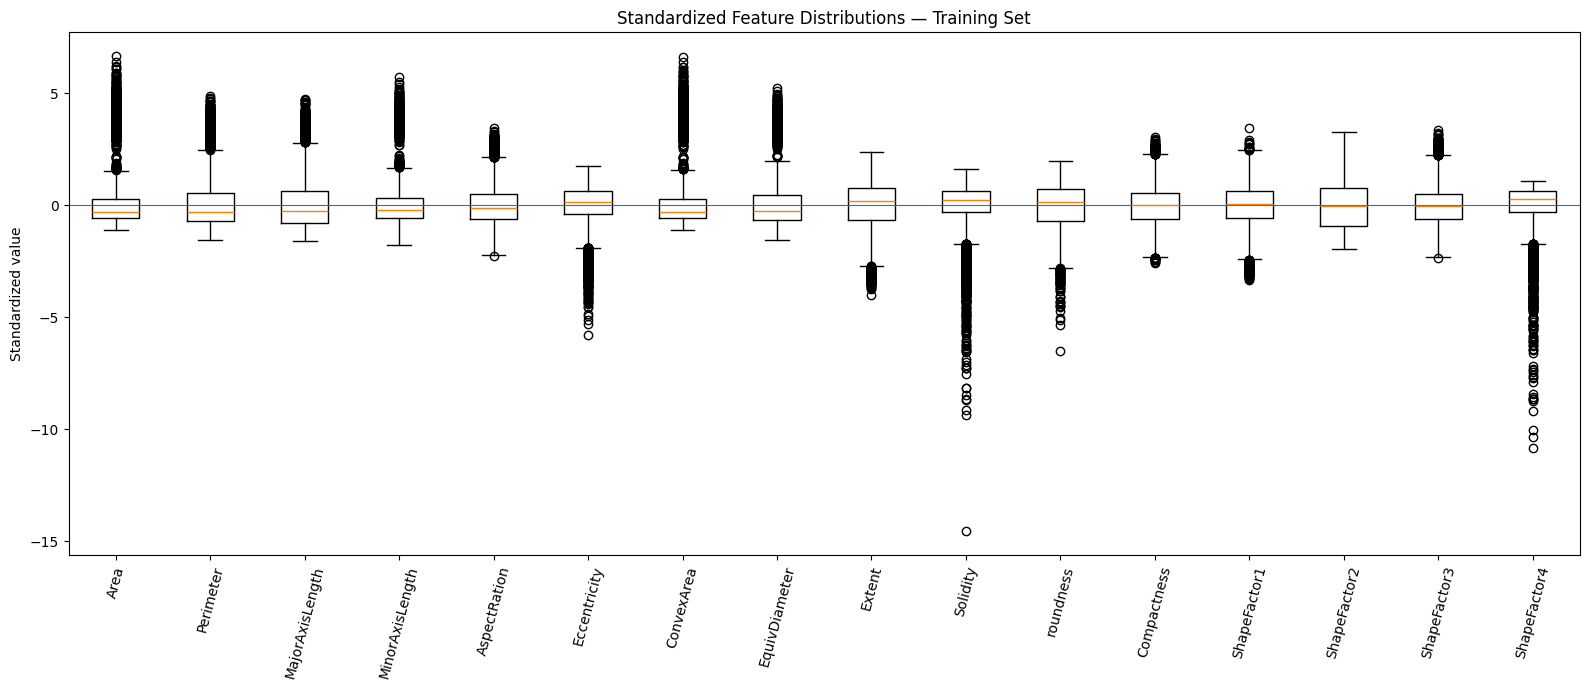

In [6]:
feature_columns = X_train.columns

eda_scaler = StandardScaler()
X_train_scaled = eda_scaler.fit_transform(X_train)

plt.figure(figsize=(16, 7))
plt.boxplot(
    X_train_scaled,
    showfliers=True,
)
plt.xticks(
    np.arange(1, len(feature_columns) + 1),
    feature_columns,
    rotation=75,
)
plt.ylabel("Standardized value")
plt.title("Standardized Feature Distributions — Training Set")
plt.axhline(0, linewidth=0.8)
plt.tight_layout()
plt.show()

The correlation structure shows strong redundancy among several geometric variables. Some relationships are nearly linear, while others reflect deterministic transformations of the same underlying size or shape information. High predictor correlation is treated as redundancy or multicollinearity rather than leakage.

In [7]:
corr_matrix = X_train.corr()

corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .rename("correlation")
    .reset_index()
)

corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

corr_pairs.sort_values(
    "abs_correlation",
    ascending=False,
).head(15)

,level_0,level_1,correlation,abs_correlation
5,Area,ConvexArea,0.999941,0.999941
112,Compactness,ShapeFactor3,0.998682,0.998682
20,Perimeter,EquivDiameter,0.991581,0.991581
60,AspectRation,Compactness,-0.987644,0.987644
75,ConvexArea,EquivDiameter,0.985364,0.985364
6,Area,EquivDiameter,0.985077,0.985077
73,Eccentricity,ShapeFactor3,-0.980988,0.980988
63,AspectRation,ShapeFactor3,-0.978519,0.978519
15,Perimeter,MajorAxisLength,0.977719,0.977719
70,Eccentricity,Compactness,-0.970211,0.970211


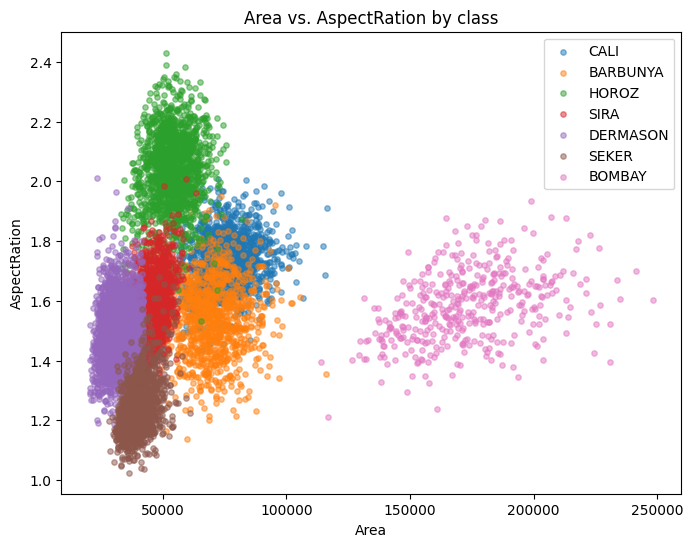

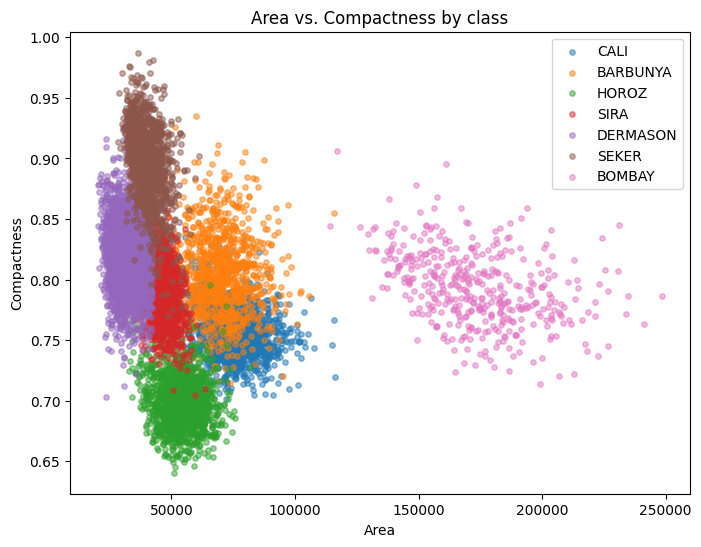

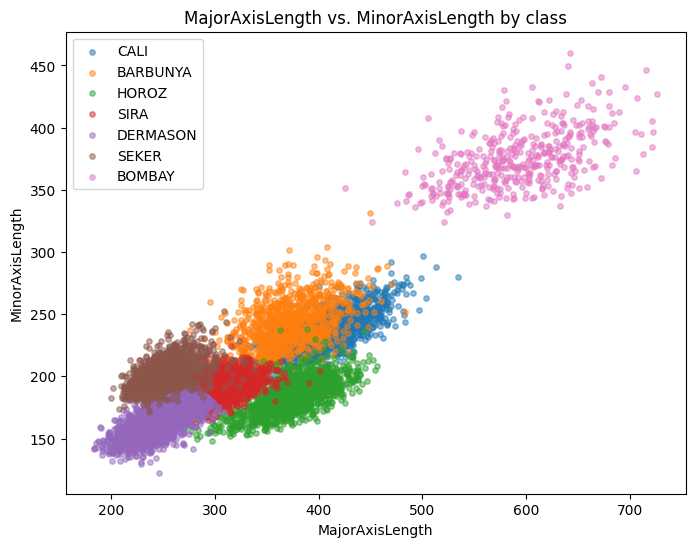

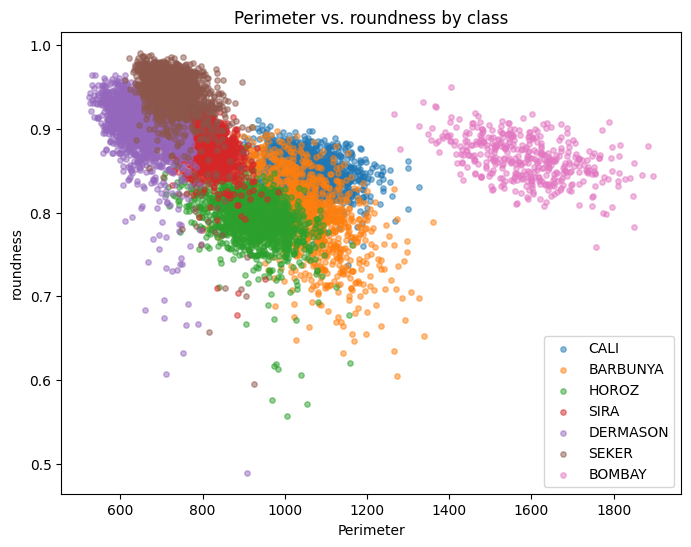

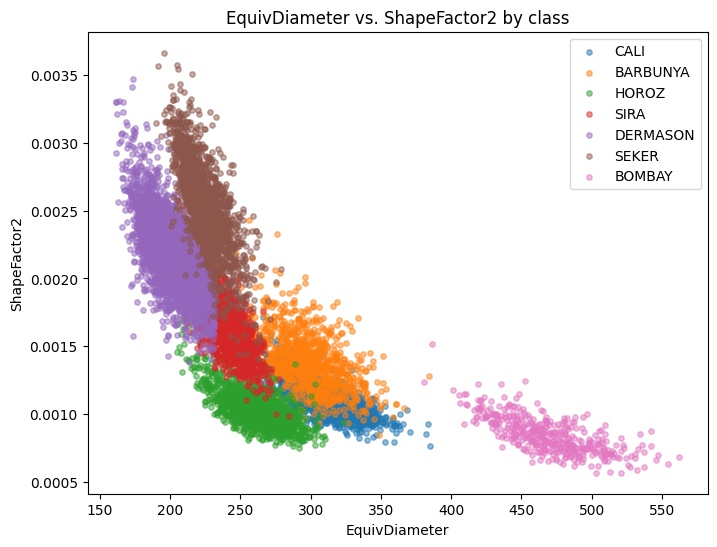

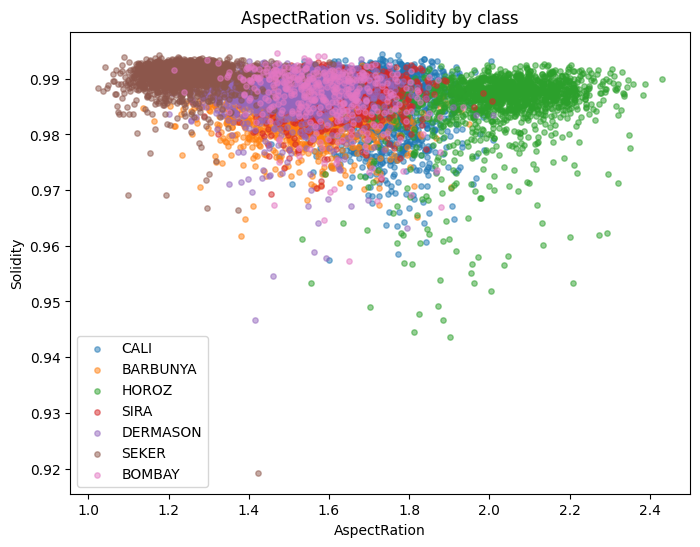

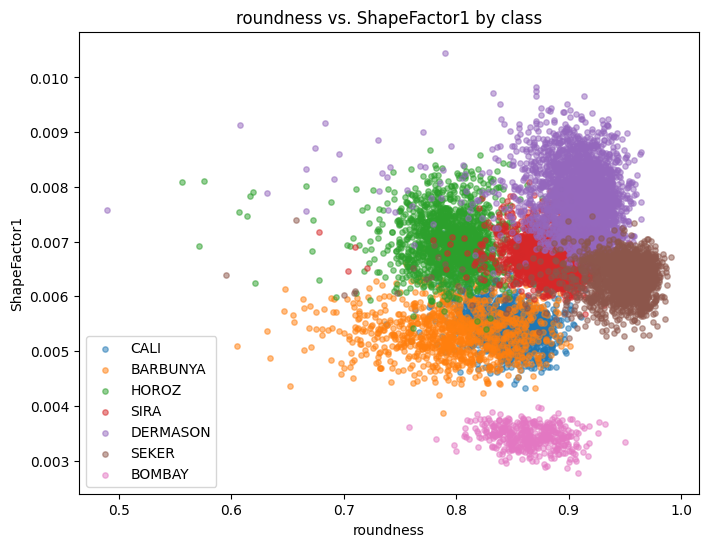

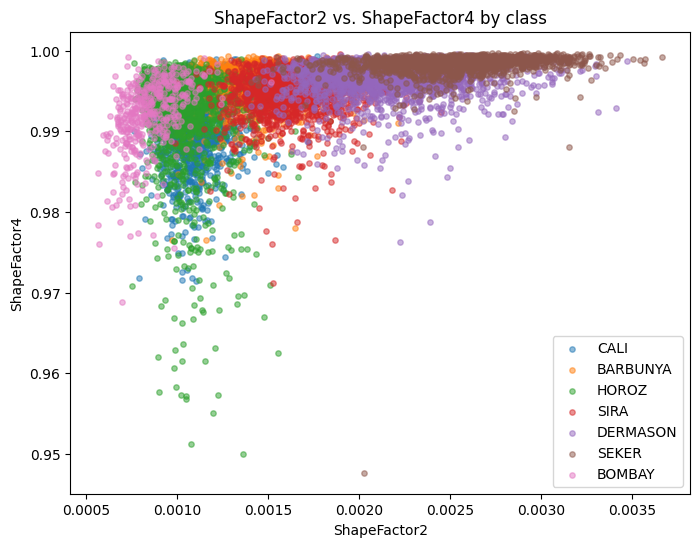

In [8]:
def plot_features_by_class(data, x, y_feature=None, class_col="Class"):
    classes = data[class_col].unique()

    if y_feature is None or x == y_feature:
        plt.figure(figsize=(8, 5))

        for cls in classes:
            values = data.loc[data[class_col] == cls, x]
            plt.hist(
                values,
                bins=30,
                alpha=0.35,
                density=True,
                label=cls,
            )

        plt.xlabel(x)
        plt.ylabel("Density")
        plt.title(f"Distribution of {x} by class")
        plt.legend()
        plt.show()
        return

    plt.figure(figsize=(8, 6))

    for cls in classes:
        subset = data.loc[data[class_col] == cls]
        plt.scatter(
            subset[x],
            subset[y_feature],
            alpha=0.5,
            s=15,
            label=cls,
        )

    plt.xlabel(x)
    plt.ylabel(y_feature)
    plt.title(f"{x} vs. {y_feature} by class")
    plt.legend()
    plt.show()


feature_pairs = [
    ("Area", "AspectRation"),
    ("Area", "Compactness"),
    ("MajorAxisLength", "MinorAxisLength"),
    ("Perimeter", "roundness"),
    ("EquivDiameter", "ShapeFactor2"),
    ("AspectRation", "Solidity"),
    ("roundness", "ShapeFactor1"),
    ("ShapeFactor2", "ShapeFactor4"),
]

for x_feature, y_feature in feature_pairs:
    plot_features_by_class(
        train_df,
        x_feature,
        y_feature,
    )

Several class pairs separate clearly in selected two-dimensional projections, while others overlap substantially. This does not imply that overlapping classes are inseparable in the full 16-dimensional space.

## 5. Derived features and redundancy

Two variables can be reconstructed from other geometric measurements.

UCI defines roundness as:

\begin{equation}
R = \frac{4\pi A}{P^2}
\end{equation}

where $A$ is `Area` and $P$ is `Perimeter`. `Compactness` is defined as the ratio between `EquivDiameter` and `MajorAxisLength`.

In [9]:
roundness_reconstructed = (
    4
    * np.pi
    * X_train["Area"]
    / np.power(X_train["Perimeter"], 2)
)

roundness_error = (
    roundness_reconstructed - X_train["roundness"]
)

compactness_reconstructed = (
    X_train["EquivDiameter"]
    / X_train["MajorAxisLength"]
)

compactness_error = (
    compactness_reconstructed - X_train["Compactness"]
)

print(
    "Roundness mean absolute reconstruction error:",
    np.abs(roundness_error).mean(),
)
print(
    "Roundness max absolute reconstruction error:",
    np.abs(roundness_error).max(),
)
print(
    "Compactness mean absolute reconstruction error:",
    np.abs(compactness_error).mean(),
)
print(
    "Compactness max absolute reconstruction error:",
    np.abs(compactness_error).max(),
)

Roundness mean absolute reconstruction error: 0.0
Roundness max absolute reconstruction error: 0.0
Compactness mean absolute reconstruction error: 2.0495163829151865e-20
Compactness max absolute reconstruction error: 1.1102230246251565e-16


`roundness` is exactly reconstructed at floating-point precision, and `Compactness` differs from its defining ratio only at numerical precision. These features therefore contribute little or no independent information, although they are retained because redundant representations can still interact differently with different model families.

## 6. Validation and preprocessing

The observations are treated as IID because the dataset does not provide temporal ordering, subject IDs, lot IDs, or capture-session IDs. A stratified five-fold cross-validation scheme is used throughout model selection.

Models that depend on feature geometry are evaluated inside a `StandardScaler` pipeline. Random Forest is evaluated without scaling.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scaled_preprocessor = Pipeline([
    ("scaler", StandardScaler()),
])


def cv_scores(model, cv, X_data, y_data):
    scoring = [
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "f1_weighted",
    ]

    results = cross_validate(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    summary = {}

    for metric in scoring:
        values = results[f"test_{metric}"]
        summary[metric] = {
            "mean": values.mean(),
            "std": values.std(),
        }

        print(
            f"{metric.replace('_', ' ').title()}: "
            f"{values.mean():.6f} ± {values.std():.6f}"
        )

    return summary

## 7. Baseline

In [11]:
baseline_model = DummyClassifier(
    strategy="most_frequent",
)

baseline_scores = cv_scores(
    baseline_model,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.261861 ± 0.000259
Balanced Accuracy: 0.142857 ± 0.000000
F1 Macro: 0.059291 ± 0.000046
F1 Weighted: 0.108683 ± 0.000192


The majority-class baseline reaches approximately 26% accuracy and exactly $1/7$ balanced accuracy, establishing a minimal reference for the multiclass task.

## 8. Multiclass model comparison

In [12]:
logistic_classifier = Pipeline([
    ("preprocessor", clone(scaled_preprocessor)),
    (
        "classifier",
        LogisticRegression(max_iter=2000),
    ),
])

logistic_scores = cv_scores(
    logistic_classifier,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.924313 ± 0.003007
Balanced Accuracy: 0.935529 ± 0.003912
F1 Macro: 0.936470 ± 0.003710
F1 Weighted: 0.924399 ± 0.002823


In [13]:
linear_svm_classifier = Pipeline([
    ("preprocessor", clone(scaled_preprocessor)),
    ("classifier", SVC(kernel="linear")),
])

linear_svm_scores = cv_scores(
    linear_svm_classifier,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.927359 ± 0.004167
Balanced Accuracy: 0.937831 ± 0.004486
F1 Macro: 0.938878 ± 0.004509
F1 Weighted: 0.927328 ± 0.004017


In [14]:
rbf_svm_classifier = Pipeline([
    ("preprocessor", clone(scaled_preprocessor)),
    ("classifier", SVC(kernel="rbf")),
])

rbf_svm_scores = cv_scores(
    rbf_svm_classifier,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.930036 ± 0.005731
Balanced Accuracy: 0.939907 ± 0.005495
F1 Macro: 0.941643 ± 0.005527
F1 Weighted: 0.930090 ± 0.005569


In [15]:
random_forest_classifier = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_scores = cv_scores(
    random_forest_classifier,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.922836 ± 0.005654
Balanced Accuracy: 0.932403 ± 0.005896
F1 Macro: 0.934137 ± 0.005442
F1 Weighted: 0.922759 ± 0.005628


Among the untuned models, the nonlinear RBF SVM produces the strongest macro F1, at approximately **0.9416**, followed closely by the linear SVM. The result suggests that nonlinear decision boundaries provide a modest benefit while the problem remains largely separable with scaled geometric features.

## 9. Out-of-fold confusion analysis

In [16]:
oof_predictions = cross_val_predict(
    rbf_svm_classifier,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1,
)

classes = np.unique(y_train)

cm_counts = pd.DataFrame(
    confusion_matrix(
        y_train,
        oof_predictions,
        labels=classes,
    ),
    index=classes,
    columns=classes,
)

cm_counts.index.name = "True Class"
cm_counts.columns.name = "Predicted Class"

cm_counts

Predicted Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
True Class,,,,,,,
BARBUNYA,963,0,61,0,3,7,23
BOMBAY,0,418,0,0,0,0,0
CALI,27,0,1246,0,18,1,12
DERMASON,0,0,0,2635,5,39,158
HOROZ,3,0,19,9,1422,0,35
SEKER,7,0,0,28,1,1541,44
SIRA,3,0,2,199,33,21,1851


In [17]:
cm_normalized = pd.DataFrame(
    confusion_matrix(
        y_train,
        oof_predictions,
        labels=classes,
        normalize="true",
    ),
    index=classes,
    columns=classes,
)

cm_normalized.index.name = "True Class"
cm_normalized.columns.name = "Predicted Class"

cm_normalized

Predicted Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
True Class,,,,,,,
BARBUNYA,0.911069,0.0,0.057711,0.000000,0.002838,0.006623,0.021760
BOMBAY,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
CALI,0.020706,0.0,0.955521,0.000000,0.013804,0.000767,0.009202
DERMASON,0.000000,0.0,0.000000,0.928798,0.001762,0.013747,0.055693
HOROZ,0.002016,0.0,0.012769,0.006048,0.955645,0.000000,0.023522
SEKER,0.004318,0.0,0.000000,0.017273,0.000617,0.950648,0.027144
SIRA,0.001422,0.0,0.000948,0.094358,0.015647,0.009957,0.877667


In [18]:
print(
    classification_report(
        y_train,
        oof_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.96      0.91      0.93      1057
      BOMBAY       1.00      1.00      1.00       418
        CALI       0.94      0.96      0.95      1304
    DERMASON       0.92      0.93      0.92      2837
       HOROZ       0.96      0.96      0.96      1488
       SEKER       0.96      0.95      0.95      1621
        SIRA       0.87      0.88      0.87      2109

    accuracy                           0.93     10834
   macro avg       0.94      0.94      0.94     10834
weighted avg       0.93      0.93      0.93     10834



`BOMBAY` is perfectly classified in the out-of-fold predictions. The lowest recalls belong to `SIRA` (**87.77%**) and `BARBUNYA` (**91.11%**).

`BARBUNYA` is most often confused with `CALI` (**5.77%**), while the dominant error for `SIRA` is `DERMASON`: **9.44%** of true `SIRA` observations are classified as `DERMASON`. The reverse confusion is smaller but still substantial, with **5.57%** of `DERMASON` classified as `SIRA`.

The per-class report confirms `SIRA` as the most difficult class, with precision around **0.87**, recall around **0.88**, and F1 around **0.87**.

## 10. Principal Component Analysis

PCA is fitted only on the training data for exploratory analysis, after standardization. Because PCA is unsupervised, explained variance describes the structure of $X$ rather than class discrimination.

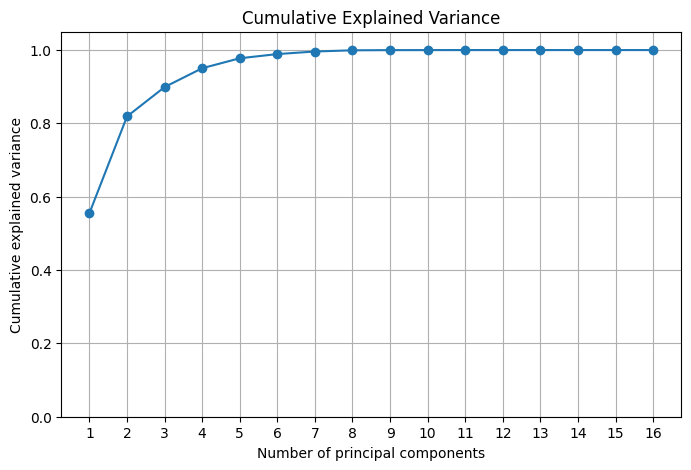

Components for 90% variance: 4
Components for 95% variance: 4
Components for 99% variance: 7


In [19]:
pca_exploration = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
])

pca_exploration.fit(X_train)

explained_variance = (
    pca_exploration["pca"].explained_variance_ratio_
)

cumulative_explained_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(
        1,
        len(cumulative_explained_variance) + 1,
    ),
    cumulative_explained_variance,
    marker="o",
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")
plt.xticks(
    np.arange(
        1,
        len(cumulative_explained_variance) + 1,
    )
)
plt.ylim(0, 1.05)
plt.grid()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n_components = (
        np.searchsorted(
            cumulative_explained_variance,
            threshold,
        )
        + 1
    )

    print(
        f"Components for {threshold:.0%} variance: "
        f"{n_components}"
    )

The 16 original features contain substantial redundancy: **4 components explain at least 95% of the variance**, while **7 components explain at least 99%**.

### Two-dimensional PCA projection

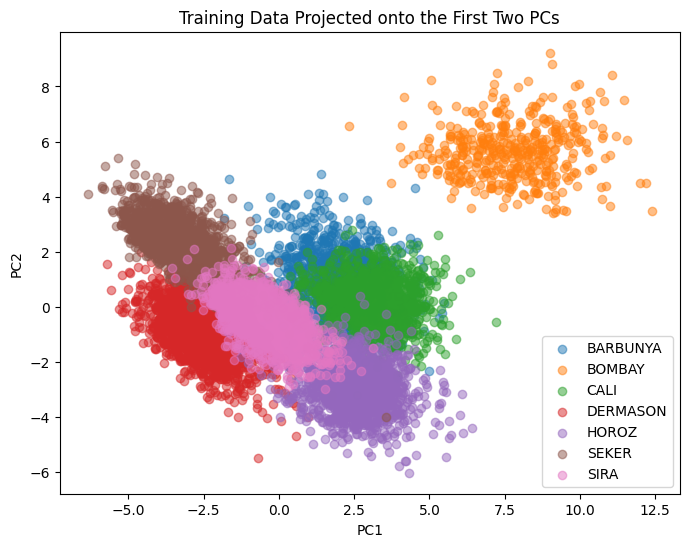

Variance explained by PC1 + PC2: 0.8189629828436563


In [20]:
pca_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
])

projected_features = pca_2d.fit_transform(
    X_train
)

plt.figure(figsize=(8, 6))

for cls in np.unique(y_train):
    mask = y_train.to_numpy() == cls

    plt.scatter(
        projected_features[mask, 0],
        projected_features[mask, 1],
        alpha=0.5,
        label=cls,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Training Data Projected onto the First Two PCs")
plt.legend()
plt.show()

print(
    "Variance explained by PC1 + PC2:",
    pca_2d["pca"].explained_variance_ratio_.sum(),
)

The first two components reveal substantial class structure without using labels during PCA. `BOMBAY` is clearly separated, while several other varieties overlap in the central region. The first two components explain roughly **82%** of total variance, so the two-dimensional projection does not preserve all potentially discriminative information.

## 11. RBF SVM with PCA

In [21]:
pca_preprocessor = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=8)),
])

rbf_svm_with_pca = Pipeline([
    ("preprocessor", pca_preprocessor),
    ("classifier", SVC(kernel="rbf")),
])

rbf_pca_scores = cv_scores(
    rbf_svm_with_pca,
    cv,
    X_train,
    y_train,
)

Accuracy: 0.930036 ± 0.005731
Balanced Accuracy: 0.939907 ± 0.005495
F1 Macro: 0.941662 ± 0.005554
F1 Weighted: 0.930092 ± 0.005572


Using **8 principal components** reduces the feature space by 50% while preserving essentially the same cross-validated performance. Macro F1 changes only from approximately **0.94164** without PCA to **0.94166** with PCA, which is negligible relative to fold-to-fold variation.

## 12. RBF SVM hyperparameter tuning

In [22]:
param_grid = [
    {
        "classifier__C": [
            10,
            30,
            100,
            300,
            1000,
        ],
        "classifier__gamma": [
            0.003,
            0.01,
            0.03,
        ],
        "preprocessor__pca__n_components": [
            2,
            4,
            8,
        ],
    },
    {
        "classifier__C": [
            10,
            30,
            100,
            300,
            1000,
        ],
        "classifier__gamma": [
            0.003,
            0.01,
            0.03,
        ],
        "preprocessor__pca": [
            "passthrough",
        ],
    },
]

search = GridSearchCV(
    rbf_svm_with_pca,
    param_grid,
    scoring=[
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "f1_weighted",
    ],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
)

search.fit(
    X_train,
    y_train,
)

best_idx = search.best_index_

best_cv_macro_f1 = (
    search.cv_results_["mean_test_f1_macro"][
        best_idx
    ]
)

best_cv_macro_f1_std = (
    search.cv_results_["std_test_f1_macro"][
        best_idx
    ]
)

print(
    "Best CV macro F1:",
    f"{best_cv_macro_f1:.6f} "
    f"± {best_cv_macro_f1_std:.6f}",
)
print("Best parameters:")
print(search.best_params_)

final_model = search.best_estimator_

Best CV macro F1: 0.944094 ± 0.005039
Best parameters:
{'classifier__C': 300, 'classifier__gamma': 0.01, 'preprocessor__pca__n_components': 8}


The search selects:

- `C = 300`
- `gamma = 0.01`
- `PCA(n_components=8)`

with mean cross-validated macro F1 of approximately **0.9441 ± 0.0050**.

## 13. Final test evaluation

In [23]:
test_predictions = final_model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions,
)
test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions,
)
test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
)
test_weighted_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted",
)

print("Accuracy:", test_accuracy)
print(
    "Balanced accuracy:",
    test_balanced_accuracy,
)
print("Macro F1:", test_macro_f1)
print("Weighted F1:", test_weighted_f1)
print()
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

Accuracy: 0.9235880398671097
Balanced accuracy: 0.9336994170769815
Macro F1: 0.9342510435041046
Weighted F1: 0.9235834529595355

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.95      0.96      0.95       406
        SIRA       0.88      0.87      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [24]:
test_classes = np.unique(y_test)

test_cm_counts = pd.DataFrame(
    confusion_matrix(
        y_test,
        test_predictions,
        labels=test_classes,
    ),
    index=test_classes,
    columns=test_classes,
)

test_cm_counts.index.name = "True Class"
test_cm_counts.columns.name = "Predicted Class"

test_cm_counts

Predicted Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
True Class,,,,,,,
BARBUNYA,241,0,16,0,0,3,5
BOMBAY,0,104,0,0,0,0,0
CALI,11,0,305,0,6,2,2
DERMASON,0,0,0,655,0,10,44
HOROZ,2,0,9,5,348,0,8
SEKER,4,0,1,5,0,390,6
SIRA,3,0,2,50,6,7,459


In [25]:
test_cm_normalized = pd.DataFrame(
    confusion_matrix(
        y_test,
        test_predictions,
        labels=test_classes,
        normalize="true",
    ),
    index=test_classes,
    columns=test_classes,
)

test_cm_normalized.index.name = "True Class"
test_cm_normalized.columns.name = (
    "Predicted Class"
)

test_cm_normalized

Predicted Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
True Class,,,,,,,
BARBUNYA,0.909434,0.0,0.060377,0.000000,0.000000,0.011321,0.018868
BOMBAY,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
CALI,0.033742,0.0,0.935583,0.000000,0.018405,0.006135,0.006135
DERMASON,0.000000,0.0,0.000000,0.923836,0.000000,0.014104,0.062059
HOROZ,0.005376,0.0,0.024194,0.013441,0.935484,0.000000,0.021505
SEKER,0.009852,0.0,0.002463,0.012315,0.000000,0.960591,0.014778
SIRA,0.005693,0.0,0.003795,0.094877,0.011385,0.013283,0.870968


The final model achieves:

- **Accuracy:** 0.9236
- **Balanced accuracy:** 0.9337
- **Macro F1:** 0.9343
- **Weighted F1:** 0.9236

The test macro F1 is about **1.0 percentage point** below the tuned cross-validation mean.

`BOMBAY` remains perfectly classified, while `SIRA` is the most difficult class with F1 around **0.87**. In test, **9.49%** of true `SIRA` observations are classified as `DERMASON`, while **6.21%** of true `DERMASON` observations are classified as `SIRA`. The same pair is also the dominant confusion in cross-validation.

## 14. Error analysis

In [26]:
error_analysis_df = X_test.copy()
error_analysis_df["y_true"] = y_test
error_analysis_df["y_pred"] = test_predictions
error_analysis_df["correct"] = (
    error_analysis_df["y_true"]
    == error_analysis_df["y_pred"]
)

main_confusion_mask = (
    (
        (y_test == "SIRA")
        & (test_predictions == "DERMASON")
    )
    | (
        (y_test == "DERMASON")
        & (test_predictions == "SIRA")
    )
)

confusion_medians = pd.DataFrame({
    "dermason_median": X_test.loc[
        y_test == "DERMASON"
    ].median(),
    "sira_median": X_test.loc[
        y_test == "SIRA"
    ].median(),
    "confused_dermason_median": X_test.loc[
        (y_test == "DERMASON")
        & main_confusion_mask
    ].median(),
    "confused_sira_median": X_test.loc[
        (y_test == "SIRA")
        & main_confusion_mask
    ].median(),
})

confusion_medians = confusion_medians.assign(
    full_abs_median_difference=lambda data: np.abs(
        data["dermason_median"]
        - data["sira_median"]
    ),
    confused_abs_median_difference=lambda data: np.abs(
        data["confused_dermason_median"]
        - data["confused_sira_median"]
    ),
)

confusion_medians

,dermason_median,sira_median,confused_dermason_median,confused_sira_median,full_abs_median_difference,confused_abs_median_difference
Area,32038.000000,44401.000000,40649.000000,37593.500000,12363.000000,3055.500000
Perimeter,665.261000,794.457000,756.089000,728.401500,129.196000,27.687500
MajorAxisLength,246.960255,297.968175,278.329609,270.117692,51.007920,8.211918
MinorAxisLength,166.752275,190.915769,182.814317,177.965182,24.163494,4.849134
AspectRation,1.486177,1.561234,1.535545,1.524026,0.075057,0.011519
Eccentricity,0.739763,0.767942,0.758865,0.754625,0.028179,0.004240
ConvexArea,32394.000000,44925.000000,41140.500000,38027.000000,12531.000000,3113.500000
EquivDiameter,201.970415,237.766922,227.499072,218.781919,35.796507,8.717153
Extent,0.753554,0.755798,0.771052,0.765805,0.002244,0.005247
Solidity,0.988856,0.988520,0.988496,0.988658,0.000336,0.000162


The `SIRA` and `DERMASON` observations that are confused with each other are substantially more similar than the full classes across many features. The reduction in median differences is especially visible for variables such as `Area`, `Perimeter`, `MajorAxisLength`, `AspectRation`, and `Compactness`. This supports the interpretation that the dominant confusion occurs in a region where the two classes have overlapping geometric characteristics.

## 15. Permutation importance

In [27]:
perm_imp = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm_imp.importances_mean,
        "Std": perm_imp.importances_std,
    })
    .sort_values(
        "Importance",
        ascending=False,
    )
)

permutation_importance_df

,Feature,Importance,Std
10,roundness,0.105847,0.004609
15,ShapeFactor4,0.097506,0.006578
4,AspectRation,0.041888,0.004074
3,MinorAxisLength,0.037459,0.003526
0,Area,0.037111,0.002982
6,ConvexArea,0.037044,0.002911
5,Eccentricity,0.035776,0.002912
1,Perimeter,0.032628,0.003559
12,ShapeFactor1,0.027403,0.003808
7,EquivDiameter,0.024424,0.002866


Permutation importance is interpreted as predictive dependence rather than causality. Because several geometric features are strongly correlated or nearly redundant, the marginal importance of an individual feature can be reduced when another feature carries similar information.

## 16. Summary

- The raw dataset contains 13,611 observations; 68 exact duplicates are removed before modeling.
- The cleaned data is divided into a stratified 80/20 train/test split, and the test set is held out before exploratory analysis.
- Scaling is essential for the SVM and PCA pipelines because the geometric variables operate on very different numerical scales.
- The feature set contains substantial redundancy, including deterministically derived `roundness` and `Compactness`.
- Among the untuned models, the RBF SVM produces the strongest macro F1.
- PCA reduces the representation from 16 features to 8 components with essentially unchanged cross-validated RBF SVM performance.
- Hyperparameter tuning selects an 8-component PCA representation with `C = 300` and `gamma = 0.01`, reaching CV macro F1 of approximately 0.9441.
- The final model achieves test macro F1 of approximately 0.9343, with the main classification difficulty concentrated in the `SIRA`–`DERMASON` pair.